# Einführung: Was ist Dask?

Dask ist eine Python-Bibliothek für **parallele** und **verteilte Berechnungen**.
Sie eignet sich besonders für Aufgaben, bei denen Datenmengen oder Berechnungen zu groß oder zu langsam für eine rein sequentielle Verarbeitung werden.
Dask orientiert sich stark an bekannten Python-Bibliotheken wie NumPy und Pandas.
Dadurch können viele **vertraute Programmierkonzepte** nahezu unverändert weiterverwendet werden.

Ein zentrales Konzept von Dask ist die **Aufteilung großer Datenmengen in kleinere Teilstücke**.
Bei **Arrays** werden diese Teilstücke als **Chunks** bezeichnet, bei **DataFrames** spricht man häufig von **Partitions**.
Diese Teilstücke können unabhängig voneinander und damit parallel verarbeitet werden.
Auf diese Weise lässt sich sowohl ein einzelner Rechner mit mehreren Prozessorkernen als auch ein Cluster aus mehreren Rechnern nutzen.

Ein weiteres wichtiges Konzept ist die sogenannte **Lazy Evaluation**.
Viele Dask-Operationen werden beim Aufruf nicht sofort ausgeführt.
Stattdessen erstellt Dask zunächst einen **Berechnungsgraphen**, den sogenannten **Task Graph**.
Dieser Graph beschreibt die **einzelnen Berechnungsschritte** und ihre **Abhängigkeiten** untereinander.

Erst durch einen Aufruf wie **compute()** wird die eigentliche Berechnung gestartet.
Ein **Scheduler** analysiert dabei den Task Graph und entscheidet, welche **Aufgaben parallel** ausgeführt werden können.
Dask unterstützt unterschiedliche Scheduler, zum Beispiel für Threads, Prozesse oder verteilte Worker auf mehreren Rechnern.

Für tabellarische Daten stellt Dask mit **dask.dataframe** eine Schnittstelle bereit, die stark an Pandas erinnert.
Mit **dask.array** können große mehrdimensionale Arrays ähnlich wie mit NumPy verarbeitet werden.
**dask.delayed** ermöglicht es außerdem, gewöhnliche Python-Funktionen in einen parallelen Berechnungsgraphen einzubinden.

Mit dem Paket dask.distributed können Berechnungen auf mehrere Worker verteilt und über ein **Dashboard** überwacht werden.
Dask ist damit besonders interessant für Data Science, wissenschaftliches Rechnen und Machine-Learning-Pipelines, bei denen Datenverarbeitung effizient parallelisiert oder über mehrere Rechner skaliert werden soll.

# Dask-Konzepte (tabellarische Uebersicht) 

| Konzept                | Bedeutung                                                                                                        |
| ---------------------- | ---------------------------------------------------------------------------------------------------------------- |
| **Dask**               | Python-Bibliothek für parallele und verteilte Berechnungen.                                                      |
| **Parallelisierung**   | Mehrere Berechnungen können gleichzeitig auf verschiedenen CPU-Kernen oder Workern ausgeführt werden.            |
| **Partitionierung**    | Große Datenmengen werden in kleinere Teile zerlegt, die unabhängig verarbeitet werden können.                    |
| **Chunks**             | Teilstücke eines `dask.array`, vergleichbar mit Blöcken eines großen NumPy-Arrays.                               |
| **Partitions**         | Teilstücke eines `dask.dataframe`, die intern meist aus einzelnen Pandas-DataFrames bestehen.                    |
| **Lazy Evaluation**    | Operationen werden zunächst nur beschrieben und noch nicht direkt ausgeführt.                                    |
| **Task Graph**         | Graph, der die einzelnen Berechnungsschritte und ihre Abhängigkeiten beschreibt.                                 |
| **`compute()`**        | Startet die tatsächliche Ausführung eines zuvor aufgebauten Dask-Berechnungsgraphen.                             |
| **Scheduler**          | Entscheidet, wann und wo einzelne Tasks ausgeführt werden.                                                       |
| **Worker**             | Prozess oder Rechner, der konkrete Tasks ausführt.                                                               |
| **`dask.array`**       | Dask-Datenstruktur für große mehrdimensionale Arrays, ähnlich zu NumPy.                                          |
| **`dask.dataframe`**   | Dask-Datenstruktur für große tabellarische Daten, ähnlich zu Pandas.                                             |
| **`dask.delayed`**     | Ermöglicht es, normale Python-Funktionen in einen Dask-Task-Graphen einzubauen.                                  |
| **`dask.distributed`** | Infrastruktur für verteilte Berechnungen mit Scheduler und mehreren Workern.                                     |
| **Dashboard**          | Weboberfläche zur Beobachtung von Tasks, CPU-Auslastung, Speicherverbrauch und Workern.                          |
| **Skalierung**         | Dask kann auf einem einzelnen Rechner mit mehreren Kernen oder auf einem Cluster mit mehreren Rechnern arbeiten. |


# Installation von Dask

| Installation                      | Bedeutung                                                      |
| --------------------------------- | -------------------------------------------------------------- |
| `pip install dask`                | Nur das Dask-Basispaket; eher minimal                          |
| `pip install "dask[distributed]"` | Dask plus **Distributed Scheduler**, Worker und Dashboard      |
| `pip install "dask[dataframe]"`   | Zusätzliche Abhängigkeiten für `dask.dataframe`                |
| `pip install "dask[array]"`       | Zusätzliche Abhängigkeiten für `dask.array`                    |
| `pip install "dask[complete]"`    | Praktisch alles, was man für typische Dask-Anwendungen braucht |


# Beispielspieldaten erzeugen

In [1]:
# Beispieldaten erzeugen

import numpy as np
import pandas as pd

N = 200_000_000

rng = np.random.default_rng(42)

# Kontinuierliche Zeitreihe mit einem Messwert pro Minute
dates = pd.date_range(
    start="2000-01-01",
    periods=N,
    freq="s"
)

df = pd.DataFrame({
    "Datum": dates,
    "ProdukteA": rng.normal(loc=100, scale=20, size=N).astype(np.int16),
    "ProdukteB": rng.normal(loc=80, scale=15, size=N).astype(np.int16)
})

# Montag = 1, Dienstag = 2, ..., Sonntag = 7
df["Wochentag"] = (df["Datum"].dt.dayofweek + 1).astype(np.int8)

In [2]:
df.head()

,Datum,ProdukteA,ProdukteB,Wochentag
0,2000-01-01 00:00:00,106,78,6
1,2000-01-01 00:00:01,79,92,6
2,2000-01-01 00:00:02,115,100,6
3,2000-01-01 00:00:03,118,87,6
4,2000-01-01 00:00:04,60,86,6


In [3]:
df.tail()

,Datum,ProdukteA,ProdukteB,Wochentag
199999995,2006-05-03 19:33:15,54,66,3
199999996,2006-05-03 19:33:16,103,58,3
199999997,2006-05-03 19:33:17,80,77,3
199999998,2006-05-03 19:33:18,106,89,3
199999999,2006-05-03 19:33:19,60,101,3


In [4]:
df.shape

(200000000, 4)

In [5]:
# Hier wird z.B. pyarrow benötigt,
# um die parquet-Datei schreiben zu können
# Kann man auch direkt angeben mit
# engine="pyarrow"
#df.to_parquet("data/verkaeufe.parquet", index=False)

df.to_parquet("data/verkaeufe.parquet", index=False,
              engine="pyarrow",  row_group_size=500_000)

Mit dem Schalter row_group_size kann man bestimmen wie gross die Row groups in der Parquet-Datei sind:

    Parquet-Datei
    ├── Row Group 1
    │   ├── Spalte Datum
    │   ├── Spalte Wochentag
    │   ├── Spalte ProdukteA
    │   └── Spalte ProdukteB
    ├── Row Group 2
    │   ├── Spalte Datum
    │   ├── Spalte Wochentag
    │   ├── Spalte ProdukteA
    │   └── Spalte ProdukteB
    └── ...

Das kombiniert zwei Vorteile:

- Zeilengruppen ermöglichen es, große Dateien in unabhängig lesbare Blöcke zu zerlegen.
- Spaltenorientierung innerhalb jeder Row Group ermöglicht es, nur die tatsächlich benötigten Spalten zu lesen.

# Exkurs: Was ist PyArrow? Apache Arrow?

- Apache Arrow ist ein offenes Format und Ökosystem für die effiziente Verarbeitung tabellarischer Daten im Arbeitsspeicher.
- Die Daten werden dabei spaltenorientiert gespeichert, was besonders für analytische Berechnungen günstig ist.
- Ein wichtiges Ziel von Arrow ist, Daten zwischen verschiedenen Programmen und Bibliotheken möglichst ohne aufwendige Kopien auszutauschen.
- Dadurch können zum Beispiel Pandas, Dask, Spark oder andere Systeme effizient mit denselben Datenstrukturen arbeiten.
- Arrow ist kein klassisches Dateiformat wie CSV, sondern vor allem ein standardisiertes Speicherformat für Daten im RAM.
- Eng verwandt damit ist Parquet, ein ebenfalls spaltenorientiertes Format für die Speicherung auf Festplatte.
- PyArrow ist die Python-Bibliothek für Apache Arrow.
- Mit PyArrow kann man unter anderem Arrow-Tabellen erzeugen, Daten konvertieren und Parquet-Dateien lesen oder schreiben.
- Pandas und Dask verwenden PyArrow häufig im Hintergrund für effiziente Parquet-Verarbeitung.
- Für viele Python-Anwendungen kann man PyArrow daher vereinfacht als die Verbindung zwischen Python-Datenstrukturen und dem Arrow-/Parquet-Ökosystem betrachten.

# Vergleich: Pandas vs. Dask (Mittelwert)

Wir berechnen den Mittelwert über Millionen von Zeilen

In [1]:
# Pandas:
import pandas as pd
from time import perf_counter

start = perf_counter()

df = pd.read_parquet("data/verkaeufe.parquet")

mean_pandas = df.loc[
    df["Wochentag"] == 2,
    "ProdukteA"
].mean()

time_pandas = perf_counter() - start

print(f"Durchschnitt ProdukteA am Dienstag: {mean_pandas:.2f}")
print(f"Pandas: {time_pandas:.3f} Sekunden")

Durchschnitt ProdukteA am Dienstag: 99.50
Pandas: 2.058 Sekunden


In [6]:
import dask.dataframe as dd
from time import perf_counter

start = perf_counter()

#ddf = dd.read_parquet("data/verkaeufe.parquet")
ddf = dd.read_parquet("data/verkaeufe.parquet", split_row_groups=True)

mean_dask = (
    ddf.loc[ddf["Wochentag"] == 2, "ProdukteA"]
    .mean()
    .compute()
)

time_dask = perf_counter() - start

print(f"Durchschnitt ProdukteA am Dienstag: {mean_dask:.2f}")
print(f"Dask: {time_dask:.3f} Sekunden")

Durchschnitt ProdukteA am Dienstag: 99.50
Dask: 1.417 Sekunden


Beachte: Dask ist Lazy, auch beim Lesen!
- d.h. dd.read_parquet() ist auch nur eine Operation im Dask Task-Graph
  und wird erst ausgeführt wenn benötigt.
- ausserdem liest Dask Daten typischerweise nicht komplett in den
  Arbeitsspeicher. Genau das ist einer seiner großen Vorteile gegenüber Pandas.
Die Daten passen ja oft gar nicht komplett in den Arbeitsspeicher.

Kurz gesagt: Dask ist out-of-core-fähig. Es kann also Daten stückweise von Platte verarbeiten, ohne den kompletten Datensatz gleichzeitig in den Arbeitsspeicher laden zu müssen.

Bei einer Anweisung wie

    result = ddf.compute()
    
ist allerdings Vorsicht geboten: Wenn ddf selbst ein sehr großer DataFrame ist, wird das Ergebnis zu einem normalen Pandas-DataFrame zusammengeführt. Dann muss dieses Ergebnis in den RAM passen.


In [7]:
(time_dask / time_pandas)*100

68.87014187987872

In [8]:
print(ddf.npartitions)

400


In [9]:
row_group_size=500_000
ddf.npartitions * row_group_size

200000000

# Weiterer Geschwindigkeitsvergleich (agg)

Aufgabe / Analyse:
- Wie viele Produkte wurden je Wochentag verkauft?
- Wie hoch war der durchschnittliche Absatz?
- Wie stark schwankten die Verkäufe?

In [11]:
import pandas as pd
from time import perf_counter

start = perf_counter()

df = pd.read_parquet("data/verkaeufe.parquet")

result_pandas = (
    df.groupby("Wochentag")
      .agg(
          durchschnitt_A=("ProdukteA", "mean"),
          durchschnitt_B=("ProdukteB", "mean"),
          summe_A=("ProdukteA", "sum"),
          summe_B=("ProdukteB", "sum"),
          std_A=("ProdukteA", "std"),
          std_B=("ProdukteB", "std")
      )
)

time_pandas = perf_counter() - start
print(f"Pandas: {time_pandas:.3f} Sekunden")

Pandas: 8.426 Sekunden


In [12]:
result_pandas

,durchschnitt_A,durchschnitt_B,summe_A,summe_B,std_A,std_B
Wochentag,,,,,,
1,99.503684,79.499699,2845646155,2273564195,20.000836,15.002753
2,99.496932,79.498317,2845453066,2273524663,20.003047,15.002055
3,99.501990,79.497556,2844005689,2272230936,20.005122,15.001199
4,99.501504,79.498170,2836986887,2266651811,19.999709,15.003572
5,99.499753,79.504300,2836936962,2266826592,20.004478,15.001409
6,99.503937,79.495467,2845653394,2273443159,19.998598,15.005246
7,99.502848,79.504979,2845622262,2273715204,19.999532,14.999945


In [13]:
import dask.dataframe as dd
from time import perf_counter

start = perf_counter()

ddf = dd.read_parquet(
    "data/verkaeufe.parquet",
    split_row_groups=True
)

result_dask = (
    ddf.groupby("Wochentag")
       .agg(
           durchschnitt_A=("ProdukteA", "mean"),
           durchschnitt_B=("ProdukteB", "mean"),
           summe_A=("ProdukteA", "sum"),
           summe_B=("ProdukteB", "sum"),
           std_A=("ProdukteA", "std"),
           std_B=("ProdukteB", "std")
       )
       .compute()
)

time_dask = perf_counter() - start
print(f"Dask: {time_dask:.3f} Sekunden")

Dask: 4.182 Sekunden


In [14]:
result_dask

,durchschnitt_A,durchschnitt_B,summe_A,summe_B,std_A,std_B
Wochentag,,,,,,
3,99.501990,79.497556,2844005689,2272230936,19.972659,15.001199
2,99.496932,79.498317,2845453066,2273524663,19.968477,15.002055
1,99.503684,79.499699,2845646155,2273564195,19.968443,15.002753
5,99.499753,79.504300,2836936962,2266826592,19.973661,15.001409
6,99.503937,79.495467,2845653394,2273443159,19.963503,15.005246
4,99.501504,79.498170,2836986887,2266651811,19.966525,15.003572
7,99.502848,79.504979,2845622262,2273715204,19.963176,14.999945


In [15]:
(time_dask / time_pandas)*100

49.62793704316785

# Pandas vs. Dask bei mehreren Parquet-Dateien

Beispielaufgabe: Uns interessiert nach Wochentag aufgeschlüsselt:

Wieviele Produkte A / B wurden verkauft?

Und wir haben viele einzelne Verkaufsdateien (z.B. 100 Stück)

## Mehrere Parquet-Dateien erzeugen

    data/verkaeufe/
        verkaeufe_00.parquet
        verkaeufe_01.parquet
        verkaeufe_02.parquet
        ...
    

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

path = Path("data/verkaeufe")
path.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(42)

N_FILES = 100
N_PER_FILE = 5_000_000

start = pd.Timestamp("2010-01-01")

for i in range(N_FILES):

    print(i, end=" ")

    dates = pd.date_range(
        start=start,
        periods=N_PER_FILE,
        freq="10s"
    )

    df = pd.DataFrame({
        "Datum": dates,
        "ProdukteA": rng.normal(100, 20, N_PER_FILE).astype(np.int16),
        "ProdukteB": rng.normal(80, 15, N_PER_FILE).astype(np.int16)
    })

    df["Wochentag"] = (df["Datum"].dt.dayofweek + 1).astype(np.int8)

    df.to_parquet(
        path / f"verkaeufe_{i:02d}.parquet",
        index=False
    )

    # nächste Datei setzt die Zeitreihe fort
    start = dates[-1] + pd.Timedelta(seconds=10)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 

## Dateien mit Pandas verarbeiten

In [10]:
import pandas as pd
from pathlib import Path
from time import perf_counter

files = sorted(Path("data/verkaeufe").glob("*.parquet"))

start = perf_counter()

results = []
for file in files:

    df = pd.read_parquet(file)
    result = (
        df.groupby("Wochentag")[["ProdukteA", "ProdukteB"]]
          .sum()
    )
    results.append(result)

# Teilergebnisse der Dateien zusammenfassen
result_pandas = (
    pd.concat(results)
      .groupby(level=0)
      .sum()
)

time_pandas = perf_counter() - start
print(f"\nPandas: {time_pandas:.3f} Sekunden")


Pandas: 10.916 Sekunden


In [11]:
result_pandas

,ProdukteA,ProdukteB
Wochentag,,
1,7106928721,5678675467
2,7106786143,5678717631
3,7106801482,5678198032
4,7107053622,5678532145
5,7108036420,5679253133
6,7107573233,5678864155
7,7106942858,5678141123


In [12]:
results[:3]

[           ProdukteA  ProdukteB
 Wochentag                      
 1           71370561   57020531
 2           71086095   56798517
 3           70506712   56322559
 4           70542443   56319728
 5           71349519   56997866
 6           71353000   56985734
 7           71376364   56996922,
            ProdukteA  ProdukteB
 Wochentag                      
 1           70480644   56306545
 2           70756885   56534980
 3           71341401   57006034
 4           71357769   57002334
 5           71334676   57003030
 6           71359016   57022453
 7           70819458   56617590,
            ProdukteA  ProdukteB
 Wochentag                      
 1           71351417   57022301
 2           71361333   57014961
 3           71361026   57007594
 4           71384952   57004494
 5           70636724   56400095
 6           70503150   56303632
 7           70992696   56714826]

## Dateien mit Dask verarbeiten

In [13]:
import dask.dataframe as dd
from time import perf_counter

start = perf_counter()

# Man beachte den *!
# Wir sagen: lese hier mehrere Dateien ein
ddf = dd.read_parquet(
    "data/verkaeufe/*.parquet"
)

result_dask = (
    ddf.groupby("Wochentag")[["ProdukteA", "ProdukteB"]]
       .sum()
       .compute()
)

time_dask = perf_counter() - start

print(f"\nDask: {time_dask:.3f} Sekunden")


Dask: 2.237 Sekunden


In [14]:
result_dask

,ProdukteA,ProdukteB
Wochentag,,
2,7106786143,5678717631
5,7108036420,5679253133
1,7106928721,5678675467
6,7107573233,5678864155
3,7106801482,5678198032
7,7106942858,5678141123
4,7107053622,5678532145


Dask sieht die einzelnen Dateien dabei als Partitionen und kann mehrere davon gleichzeitig bearbeiten:

    Datei 1 ─→ Worker ─→ Teilresultat ─┐
    Datei 2 ─→ Worker ─→ Teilresultat ─┤
    Datei 3 ─→ Worker ─→ Teilresultat ─┤
    Datei 4 ─→ Worker ─→ Teilresultat ─┤
    ...                                ├─→ Gesamtergebnis
    Datei 24 ─→ Worker → Teilresultat ─┘

In [15]:
print(ddf.npartitions)

100


## Zeitvergleich

In [16]:
print(f"Pandas: {time_pandas:.3f} s")
print(f"Dask:   {time_dask:.3f} s")

print(
    f"Dask benötigt "
    f"{time_dask / time_pandas * 100:.1f} % "
    f"der Pandas-Zeit."
)

print(
    f"Speedup: "
    f"{time_pandas / time_dask:.2f}x"
)

Pandas: 10.916 s
Dask:   2.237 s
Dask benötigt 20.5 % der Pandas-Zeit.
Speedup: 4.88x


# Vergleich: Zeireihenglättung Pandas vs. Dask

## Das Problem mit den Partitionsgrenzen

Bei einer Rolling-Berechnung gibt es ein kleines Problem an den Partitionsgrenzen.

Angenommen:

    Partition 1                     Partition 2
    
    ... 10:59:40  10:59:50 | 11:00:00  11:00:10 ...
                           ^
                    Partitionsgrenze

Für den gleitenden Stundenmittelwert bei 11:00:00 benötigt Dask auch Werte aus Partition 1.

Dask muss deshalb Daten an den Partitionsgrenzen überlappend berücksichtigen. Das ist ein sehr schönes Beispiel dafür, dass eine Partitionierung nicht einfach bedeutet:

    „Jede Datei völlig unabhängig berechnen.“

Bei Operationen wie rolling() müssen benachbarte Partitionen Daten austauschen.

Hier werden also drei wichtige Dask-Ideen gleichzeitig sichtbar:

    viele Dateien → 1. Partitionen → 2. parallele Verarbeitung, aber gleichzeitig 3. Abhängigkeiten zwischen Partitionen bei Rolling Windows.

## Dask Berechnungsgraphen aufbauen, Dashboard starten, compute()

In [11]:
import dask.dataframe as dd
import matplotlib.pyplot as plt

from pathlib import Path
from time import perf_counter
from dask.distributed import Client

# --------------------------------------------------
# 0. Dask Client starten
# --------------------------------------------------
client = Client()
print(client)
print("Dashboard:", client.dashboard_link)


# --------------------------------------------------
# 1. Daten einlesen
# --------------------------------------------------
path = Path("data/verkaeufe")
ddf = dd.read_parquet(
    path / "*.parquet",
    columns=["Datum", "ProdukteA"]
)
ddf = ddf.set_index(
    "Datum",
    sorted=True
)
print(f"Anzahl Partitionen: {ddf.npartitions}")


# --------------------------------------------------
# 2. Daten auf Minutenebene verdichten
# --------------------------------------------------
pro_minute = ddf["ProdukteA"].resample("1min").mean()


# --------------------------------------------------
# 3. Zeitreihe glätten
# --------------------------------------------------
geglaettet = pro_minute.rolling("1h").mean()

/home/juebrauer/miniconda3/envs/env_teaching/lib/python3.12/site-packages/distributed/node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 44171 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:33951' processes=4 threads=16, memory=31.05 GiB>
Dashboard: http://127.0.0.1:44171/status
Anzahl Partitionen: 50


Berechnungszeit mit Dask: 29.54 Sekunden


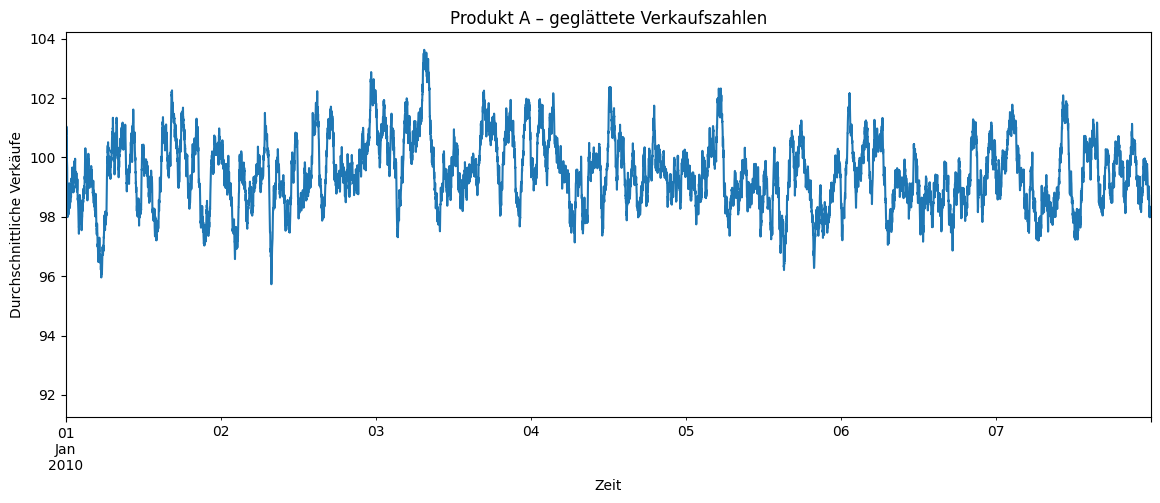

In [12]:
# --------------------------------------------------
# 4. Berechnung starten
# --------------------------------------------------
start = perf_counter()
result = geglaettet.compute()
dauer = perf_counter() - start
print(f"Berechnungszeit mit Dask: {dauer:.2f} Sekunden")


# --------------------------------------------------
# 5. Ausschnitt darstellen
# --------------------------------------------------
ausschnitt = result.loc["2010-01-01":"2010-01-07"]
ausschnitt.plot(
    figsize=(14, 5),
    title="Produkt A – geglättete Verkaufszahlen"
)
plt.xlabel("Zeit")
plt.ylabel("Durchschnittliche Verkäufe")
plt.show()

## Hinweis zu sorted=True

sorted=True sagt Dask:

    Die Werte in der Spalte Datum sind bereits global sortiert.

Das ist wichtig, weil set_index() sonst normalerweise teuer werden kann.

Ohne:

    ddf = ddf.set_index("Datum")

muss Dask unter Umständen die Daten neu verteilen und sortieren, damit nachher jede Partition einen sauberen, geordneten Indexbereich enthält. Das kann einen sogenannten Shuffle auslösen und viel Zeit sowie Speicher kosten.